In [1]:
# ============================================================
# CELL 1 — SETUP
# ============================================================
!pip install statsmodels linearmodels -q

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/ECB_Research/ECB_Project'
DATA_PATH  = f'{DRIVE_ROOT}/output/lp_dataset.csv'

print("✅ Setup completo")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.8 MB/s eta 0:00:00
Mounted at /content/drive
✅ Setup completo


In [2]:
# ============================================================
# CELL 2 — CARICA DATI
# ============================================================
df = pd.read_csv(DATA_PATH, parse_dates=['meeting_date'])
df = df.sort_values('meeting_date').reset_index(drop=True)

# Variabili chiave
df['surprise']   = df['dfr_surprise_mech']          # sorpresa monetaria (bp)
df['shock_pos']  = df['surprise'].clip(lower=0)      # sorprese hawkish
df['shock_neg']  = df['surprise'].clip(upper=0)      # sorprese dovish
df['t']          = np.arange(len(df))                # trend temporale

print(f"✅ Dataset: {len(df)} meeting ({df['meeting_date'].min().date()} → {df['meeting_date'].max().date()})")
print(f"\nVariabili disponibili:")
print(f"  surprise:   mean={df['surprise'].mean():.2f}bp, std={df['surprise'].std():.2f}bp")
print(f"  hicp_yoy:   mean={df['hicp_yoy'].mean():.2f}%, std={df['hicp_yoy'].std():.2f}%")
print(f"  gdp_yoy:    mean={df['gdp_yoy'].mean():.2f}%, std={df['gdp_yoy'].std():.2f}%")
print(f"  unemp_rate: mean={df['unemp_rate'].mean():.2f}%, std={df['unemp_rate'].std():.2f}%")

✅ Dataset: 312 meeting (1999-03-04 → 2025-12-18)

Variabili disponibili:
  surprise:   mean=-1.12bp, std=13.54bp
  hicp_yoy:   mean=2.06%, std=1.52%
  gdp_yoy:    mean=1.54%, std=2.60%
  unemp_rate: mean=9.06%, std=1.54%


In [3]:
# ============================================================
# CELL 3 — LOCAL PROJECTIONS (Jordà 2005)
# ============================================================

def local_projection(df, y_var, shock_var, controls, H=12, lags=2):
    """
    Stima LP per ogni orizzonte h=0,...,H.

    Modello: y(t+h) - y(t-1) = alpha + beta_h * shock(t) + controls + lags + eps

    Returns: DataFrame con beta, se, ci_lower, ci_upper per ogni h
    """
    results = []

    for h in range(H + 1):
        rows = []
        for i in range(lags, len(df) - h):
            # Variabile dipendente: variazione cumulativa
            y_future = df[y_var].iloc[i + h]
            y_past   = df[y_var].iloc[i - 1]
            if pd.isna(y_future) or pd.isna(y_past):
                continue

            dep_var = y_future - y_past
            shock   = df[shock_var].iloc[i]

            row = {'dep': dep_var, 'shock': shock}

            # Controlli
            for c in controls:
                row[c] = df[c].iloc[i]

            # Lags della variabile dipendente
            for lag in range(1, lags + 1):
                y_lag = df[y_var].iloc[i - lag]
                y_lag_prev = df[y_var].iloc[i - lag - 1] if i - lag - 1 >= 0 else np.nan
                row[f'dy_lag{lag}'] = y_lag - y_lag_prev if not pd.isna(y_lag) and not pd.isna(y_lag_prev) else 0

            rows.append(row)

        if not rows:
            continue

        reg_df = pd.DataFrame(rows).dropna()
        if len(reg_df) < 20:
            continue

        # Regressione OLS con SE robusti (Newey-West)
        y = reg_df['dep']
        X_cols = ['shock'] + controls + [f'dy_lag{l}' for l in range(1, lags + 1)]
        X_cols = [c for c in X_cols if c in reg_df.columns]
        X = sm.add_constant(reg_df[X_cols])

        model  = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h + 1})

        beta = model.params['shock']
        se   = model.bse['shock']

        results.append({
            'h':        h,
            'beta':     beta,
            'se':       se,
            'ci_lower': beta - 1.96 * se,
            'ci_upper': beta + 1.96 * se,
            'ci_lower_90': beta - 1.645 * se,
            'ci_upper_90': beta + 1.645 * se,
            'nobs':     int(model.nobs),
            'pvalue':   model.pvalues['shock']
        })

    return pd.DataFrame(results)


# ── Stima LP per HICP ────────────────────────────────────────
controls = ['hicp_yoy', 'gdp_yoy']

print("Stimando LP per HICP...")
lp_hicp = local_projection(
    df=df,
    y_var='hicp_yoy',
    shock_var='surprise',
    controls=controls,
    H=12,
    lags=2
)

print("Stimando LP per GDP...")
lp_gdp = local_projection(
    df=df,
    y_var='gdp_yoy',
    shock_var='surprise',
    controls=['hicp_yoy', 'gdp_yoy'],
    H=12,
    lags=2
)

print(f"\n✅ LP HICP stimata su {lp_hicp['nobs'].mean():.0f} obs in media")
print(f"✅ LP GDP  stimata su {lp_gdp['nobs'].mean():.0f} obs in media")
print(f"\nCoefficienti HICP (beta_h):")
print(lp_hicp[['h','beta','se','pvalue']].round(4).to_string(index=False))

Stimando LP per HICP...
Stimando LP per GDP...

✅ LP HICP stimata su 304 obs in media
✅ LP GDP  stimata su 304 obs in media

Coefficienti HICP (beta_h):
 h    beta     se  pvalue
 0  0.0001 0.0017  0.9529
 1  0.0001 0.0031  0.9693
 2 -0.0013 0.0041  0.7546
 3 -0.0035 0.0051  0.4935
 4 -0.0041 0.0062  0.5071
 5 -0.0059 0.0072  0.4145
 6 -0.0052 0.0083  0.5293
 7 -0.0045 0.0092  0.6281
 8 -0.0049 0.0100  0.6243
 9 -0.0043 0.0108  0.6870
10 -0.0024 0.0112  0.8311
11 -0.0029 0.0113  0.7967
12 -0.0024 0.0113  0.8298


In [4]:
# ============================================================
# CELL 5 — LP A FREQUENZA MENSILE (metodologia corretta)
# ============================================================

# ── Costruisci serie mensile ──────────────────────────────────
# Crea griglia mensile 1999-2025
monthly_index = pd.date_range('1999-01-31', '2025-12-31', freq='ME')
monthly = pd.DataFrame({'date': monthly_index})

# Aggiungi variabili macro — già mensili
hicp_m = df[['meeting_date', 'hicp_yoy']].copy()
hicp_m['date'] = hicp_m['meeting_date'] + pd.offsets.MonthEnd(0)
hicp_m = hicp_m.groupby('date')['hicp_yoy'].first().reset_index()

gdp_m = df[['meeting_date', 'gdp_yoy']].copy()
gdp_m['date'] = gdp_m['meeting_date'] + pd.offsets.MonthEnd(0)
gdp_m = gdp_m.groupby('date')['gdp_yoy'].first().reset_index()

unemp_m = df[['meeting_date', 'unemp_rate']].copy()
unemp_m['date'] = unemp_m['meeting_date'] + pd.offsets.MonthEnd(0)
unemp_m = unemp_m.groupby('date')['unemp_rate'].first().reset_index()

# Aggrega sorprese per mese — somma se ci sono più meeting nello stesso mese
surprise_m = df[['meeting_date', 'dfr_surprise_mech']].copy()
surprise_m['date'] = surprise_m['meeting_date'] + pd.offsets.MonthEnd(0)
surprise_m = surprise_m.groupby('date')['dfr_surprise_mech'].sum().reset_index()
surprise_m.columns = ['date', 'surprise']

# Merge tutto sulla griglia mensile
monthly = monthly.merge(surprise_m, on='date', how='left')
monthly['surprise'] = monthly['surprise'].fillna(0)  # mesi senza meeting = 0
monthly = monthly.merge(hicp_m, on='date', how='left')
monthly = monthly.merge(gdp_m, on='date', how='left')
monthly = monthly.merge(unemp_m, on='date', how='left')

# Forward fill GDP (trimestrale)
monthly['gdp_yoy'] = monthly['gdp_yoy'].ffill()

# Shocks positivi e negativi
monthly['shock_pos'] = monthly['surprise'].clip(lower=0)
monthly['shock_neg'] = monthly['surprise'].clip(upper=0)

print(f"✅ Dataset mensile: {len(monthly)} mesi")
print(f"   Mesi con almeno un meeting: {(monthly['surprise'] != 0).sum()}")
print(f"   Mesi senza meeting: {(monthly['surprise'] == 0).sum()}")
print(f"\n   Null per variabile:")
for col in ['hicp_yoy', 'gdp_yoy', 'unemp_rate', 'surprise']:
    print(f"     {col}: {monthly[col].isna().sum()}")

✅ Dataset mensile: 324 mesi
   Mesi con almeno un meeting: 270
   Mesi senza meeting: 54

   Null per variabile:
     hicp_yoy: 49
     gdp_yoy: 2
     unemp_rate: 59
     surprise: 0


In [5]:
# ============================================================
# CELL 6 — STIMA LP MENSILE
# ============================================================

def lp_monthly(data, y_var, shock_var, controls, H=24, lags=3):
    """
    LP a frequenza mensile.
    h = orizzonti in mesi (0, 1, ..., H)
    """
    results = []

    for h in range(H + 1):
        rows = []
        for i in range(lags, len(data) - h):
            y_future = data[y_var].iloc[i + h]
            y_past   = data[y_var].iloc[i - 1]
            if pd.isna(y_future) or pd.isna(y_past):
                continue

            row = {
                'dep':   y_future - y_past,
                shock_var: data[shock_var].iloc[i],
            }
            for c in controls:
                val = data[c].iloc[i]
                if pd.isna(val):
                    row = None
                    break
                row[c] = val

            if row is None:
                continue

            for lag in range(1, lags + 1):
                y_lag      = data[y_var].iloc[i - lag]
                y_lag_prev = data[y_var].iloc[i - lag - 1] if i - lag - 1 >= 0 else np.nan
                row[f'dy_lag{lag}'] = y_lag - y_lag_prev if not pd.isna(y_lag) and not pd.isna(y_lag_prev) else 0

            rows.append(row)

        reg_df = pd.DataFrame(rows).dropna()
        if len(reg_df) < 30:
            continue

        y = reg_df['dep']
        X_cols = [shock_var] + controls + [f'dy_lag{l}' for l in range(1, lags + 1)]
        X_cols = [c for c in X_cols if c in reg_df.columns]
        X = sm.add_constant(reg_df[X_cols])

        model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': max(h, 1)})

        beta = model.params[shock_var]
        se   = model.bse[shock_var]

        results.append({
            'h':           h,
            'beta':        beta,
            'se':          se,
            'ci_lower':    beta - 1.96 * se,
            'ci_upper':    beta + 1.96 * se,
            'ci_lower_90': beta - 1.645 * se,
            'ci_upper_90': beta + 1.645 * se,
            'nobs':        int(model.nobs),
            'pvalue':      model.pvalues[shock_var]
        })

    return pd.DataFrame(results)


controls = ['hicp_yoy', 'gdp_yoy']

print("Stimando LP mensile — HICP (simmetrica)...")
lp_hicp_m = lp_monthly(monthly, 'hicp_yoy', 'surprise', controls, H=24, lags=3)

print("Stimando LP mensile — GDP (simmetrica)...")
lp_gdp_m = lp_monthly(monthly, 'gdp_yoy', 'surprise', controls, H=24, lags=3)

print("Stimando LP mensile — HICP (hawkish)...")
lp_hicp_pos = lp_monthly(monthly, 'hicp_yoy', 'shock_pos', controls, H=24, lags=3)

print("Stimando LP mensile — HICP (dovish)...")
lp_hicp_neg = lp_monthly(monthly, 'hicp_yoy', 'shock_neg', controls, H=24, lags=3)

print("Stimando LP mensile — GDP (hawkish)...")
lp_gdp_pos = lp_monthly(monthly, 'gdp_yoy', 'shock_pos', controls, H=24, lags=3)

print("Stimando LP mensile — GDP (dovish)...")
lp_gdp_neg = lp_monthly(monthly, 'gdp_yoy', 'shock_neg', controls, H=24, lags=3)

print(f"\n✅ Stime completate")
print(f"   HICP: {len(lp_hicp_m)} orizzonti, media obs={lp_hicp_m['nobs'].mean():.0f}")
print(f"   GDP:  {len(lp_gdp_m)} orizzonti, media obs={lp_gdp_m['nobs'].mean():.0f}")
print(f"\nCoefficienti HICP — primi 12 mesi:")
print(lp_hicp_m[['h','beta','se','pvalue']].head(13).round(5).to_string(index=False))

Stimando LP mensile — HICP (simmetrica)...
Stimando LP mensile — GDP (simmetrica)...
Stimando LP mensile — HICP (hawkish)...
Stimando LP mensile — HICP (dovish)...
Stimando LP mensile — GDP (hawkish)...
Stimando LP mensile — GDP (dovish)...

✅ Stime completate
   HICP: 25 orizzonti, media obs=205
   GDP:  25 orizzonti, media obs=266

Coefficienti HICP — primi 12 mesi:
 h     beta      se  pvalue
 0  0.00183 0.00168 0.27637
 1  0.00423 0.00335 0.20608
 2  0.00275 0.00404 0.49585
 3  0.00274 0.00519 0.59694
 4  0.00265 0.00612 0.66501
 5 -0.00021 0.00640 0.97430
 6  0.00024 0.00760 0.97474
 7  0.00568 0.00925 0.53937
 8  0.00183 0.00933 0.84438
 9  0.00131 0.00974 0.89306
10  0.00062 0.00979 0.94940
11  0.00151 0.01095 0.89015
12 -0.00019 0.01009 0.98503


Stimando LP normalizzate...
✅ Stime completate


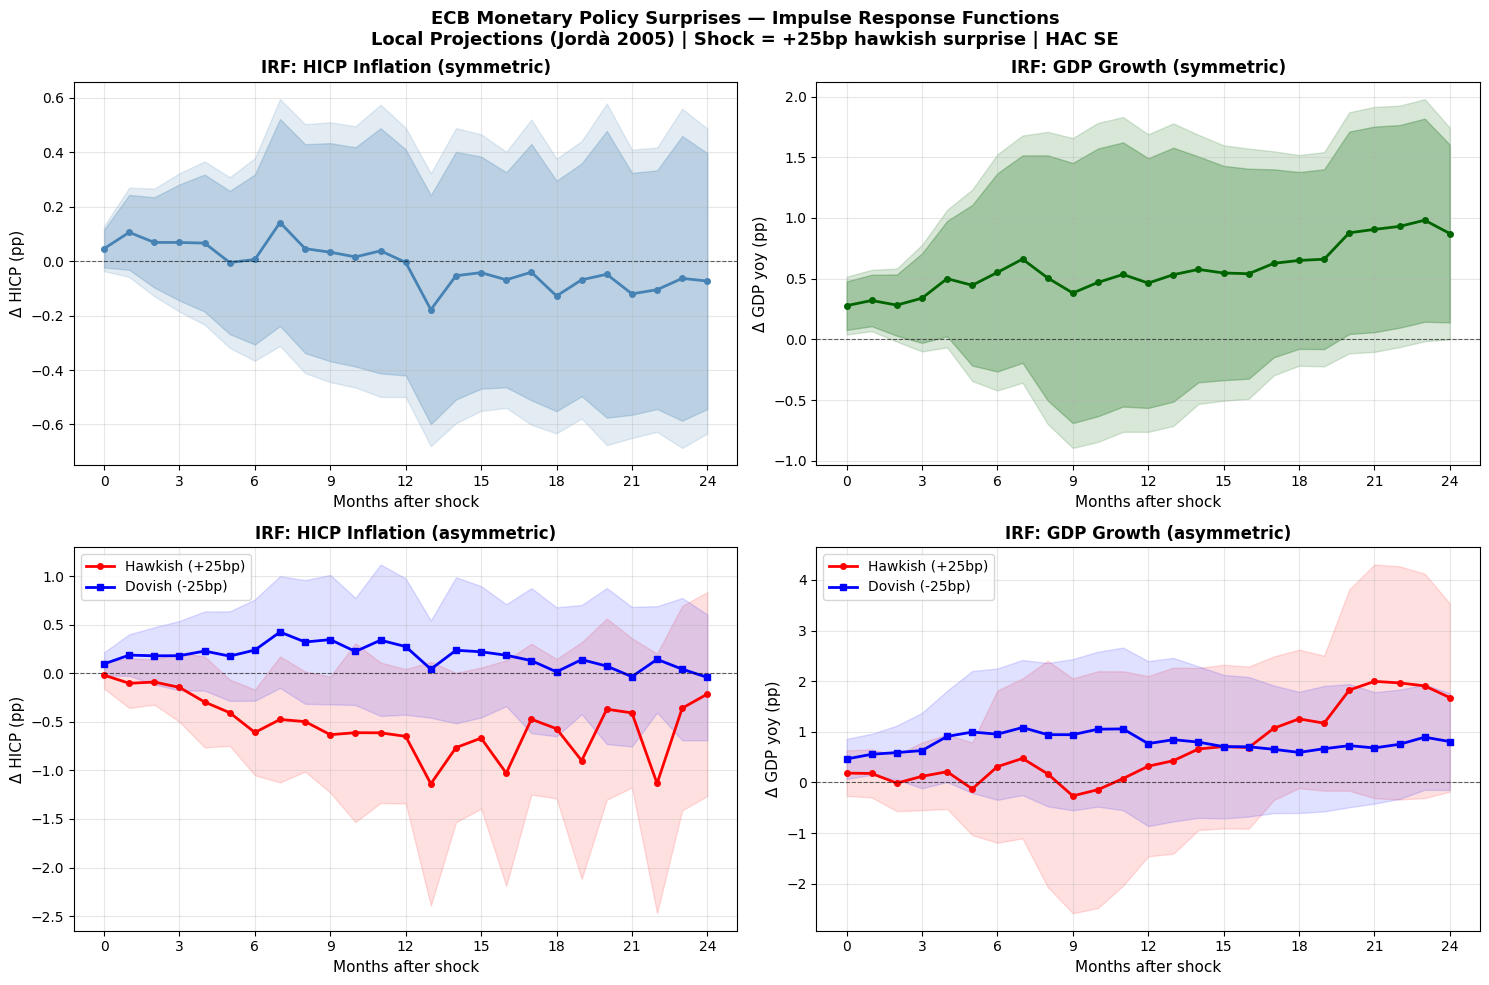

✅ Grafici salvati su Drive


In [6]:
# ============================================================
# CELL 7 — NORMALIZZAZIONE + GRAFICI IRF
# ============================================================

# Normalizza la sorpresa a 25bp (un taglio/rialzo standard)
# Così i coefficienti si interpretano come effetto di un rialzo da 25bp
scale = 25.0
monthly['surprise_n']  = monthly['surprise']  / scale
monthly['shock_pos_n'] = monthly['shock_pos'] / scale
monthly['shock_neg_n'] = monthly['shock_neg'] / scale

controls = ['hicp_yoy', 'gdp_yoy']

print("Stimando LP normalizzate...")
lp_hicp_n     = lp_monthly(monthly, 'hicp_yoy', 'surprise_n',  controls, H=24, lags=3)
lp_gdp_n      = lp_monthly(monthly, 'gdp_yoy',  'surprise_n',  controls, H=24, lags=3)
lp_hicp_pos_n = lp_monthly(monthly, 'hicp_yoy', 'shock_pos_n', controls, H=24, lags=3)
lp_hicp_neg_n = lp_monthly(monthly, 'hicp_yoy', 'shock_neg_n', controls, H=24, lags=3)
lp_gdp_pos_n  = lp_monthly(monthly, 'gdp_yoy',  'shock_pos_n', controls, H=24, lags=3)
lp_gdp_neg_n  = lp_monthly(monthly, 'gdp_yoy',  'shock_neg_n', controls, H=24, lags=3)

print("✅ Stime completate")

# ── Grafici ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('ECB Monetary Policy Surprises — Impulse Response Functions\n'
             'Local Projections (Jordà 2005) | Shock = +25bp hawkish surprise | HAC SE',
             fontsize=13, fontweight='bold')

def plot_irf(ax, lp, title, ylabel, color='steelblue'):
    ax.fill_between(lp['h'], lp['ci_lower'], lp['ci_upper'],
                    alpha=0.15, color=color)
    ax.fill_between(lp['h'], lp['ci_lower_90'], lp['ci_upper_90'],
                    alpha=0.25, color=color)
    ax.plot(lp['h'], lp['beta'], color=color, linewidth=2,
            marker='o', markersize=4, label='Point estimate')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Months after shock', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 25, 3))

def plot_irf_asym(ax, lp_pos, lp_neg, title, ylabel):
    ax.fill_between(lp_pos['h'], lp_pos['ci_lower'], lp_pos['ci_upper'],
                    alpha=0.12, color='red')
    ax.plot(lp_pos['h'], lp_pos['beta'], color='red', linewidth=2,
            marker='o', markersize=4, label='Hawkish (+25bp)')
    ax.fill_between(lp_neg['h'], lp_neg['ci_lower'], lp_neg['ci_upper'],
                    alpha=0.12, color='blue')
    ax.plot(lp_neg['h'], lp_neg['beta'], color='blue', linewidth=2,
            marker='s', markersize=4, label='Dovish (-25bp)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Months after shock', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 25, 3))

plot_irf(axes[0,0], lp_hicp_n,
         'IRF: HICP Inflation (symmetric)',
         'Δ HICP (pp)', color='steelblue')

plot_irf(axes[0,1], lp_gdp_n,
         'IRF: GDP Growth (symmetric)',
         'Δ GDP yoy (pp)', color='darkgreen')

plot_irf_asym(axes[1,0], lp_hicp_pos_n, lp_hicp_neg_n,
              'IRF: HICP Inflation (asymmetric)',
              'Δ HICP (pp)')

plot_irf_asym(axes[1,1], lp_gdp_pos_n, lp_gdp_neg_n,
              'IRF: GDP Growth (asymmetric)',
              'Δ GDP yoy (pp)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ECB_Research/ECB_Project/output/lp_irfs_monthly.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafici salvati su Drive")

In [7]:
# ============================================================
# CELL 8 — WALD TEST ASIMMETRIA + CONTROLLO ENDOGENEITÀ
# ============================================================

from scipy.stats import chi2

def lp_monthly_joint(data, y_var, controls, H=24, lags=3):
    """
    LP con shock_pos e shock_neg nella stessa regressione.
    Permette test di Wald per H0: beta_pos = beta_neg
    """
    results = []

    for h in range(H + 1):
        rows = []
        for i in range(lags, len(data) - h):
            y_future = data[y_var].iloc[i + h]
            y_past   = data[y_var].iloc[i - 1]
            if pd.isna(y_future) or pd.isna(y_past):
                continue

            row = {
                'dep':       y_future - y_past,
                'shock_pos': data['shock_pos_n'].iloc[i],
                'shock_neg': data['shock_neg_n'].iloc[i],
            }
            skip = False
            for c in controls:
                val = data[c].iloc[i]
                if pd.isna(val):
                    skip = True
                    break
                row[c] = val
            if skip:
                continue

            for lag in range(1, lags + 1):
                y_lag      = data[y_var].iloc[i - lag]
                y_lag_prev = data[y_var].iloc[i - lag - 1] if i - lag - 1 >= 0 else np.nan
                row[f'dy_lag{lag}'] = y_lag - y_lag_prev if not pd.isna(y_lag) and not pd.isna(y_lag_prev) else 0

            rows.append(row)

        reg_df = pd.DataFrame(rows).dropna()
        if len(reg_df) < 30:
            continue

        y = reg_df['dep']
        X_cols = ['shock_pos', 'shock_neg'] + controls + [f'dy_lag{l}' for l in range(1, lags + 1)]
        X_cols = [c for c in X_cols if c in reg_df.columns]
        X = sm.add_constant(reg_df[X_cols])
        model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': max(h, 1)})

        b_pos  = model.params['shock_pos']
        b_neg  = model.params['shock_neg']
        se_pos = model.bse['shock_pos']
        se_neg = model.bse['shock_neg']

        # Wald test: H0: beta_pos = beta_neg
        # Matrice di covarianza per i due coefficienti
        cov_matrix = model.cov_params()
        R = np.array([[1, -1]])  # beta_pos - beta_neg = 0
        idx_pos = list(model.params.index).index('shock_pos')
        idx_neg = list(model.params.index).index('shock_neg')
        V = cov_matrix.iloc[[idx_pos, idx_neg], [idx_pos, idx_neg]].values
        b_diff = b_pos - b_neg
        wald_stat = float((b_diff**2) / (R @ V @ R.T))
        wald_pval = 1 - chi2.cdf(wald_stat, df=1)

        results.append({
            'h':           h,
            'beta_pos':    b_pos,
            'beta_neg':    b_neg,
            'se_pos':      se_pos,
            'se_neg':      se_neg,
            'ci_pos_lo':   b_pos - 1.96 * se_pos,
            'ci_pos_hi':   b_pos + 1.96 * se_pos,
            'ci_neg_lo':   b_neg - 1.96 * se_neg,
            'ci_neg_hi':   b_neg + 1.96 * se_neg,
            'wald_stat':   wald_stat,
            'wald_pval':   wald_pval,
            'asymmetric':  wald_pval < 0.10,  # significativo al 10%
            'nobs':        int(model.nobs),
        })

    return pd.DataFrame(results)


# ── Stima con controllo endogeneità ──────────────────────────
# Aggiungiamo output gap proxy (deviazione PIL dalla media mobile)
monthly['gdp_trend']    = monthly['gdp_yoy'].rolling(12, min_periods=6).mean()
monthly['gdp_gap']      = monthly['gdp_yoy'] - monthly['gdp_trend']

# Controls estesi con GDP gap per controllare il ciclo
controls_ext = ['hicp_yoy', 'gdp_yoy', 'gdp_gap']

print("Stimando LP congiunta HICP con controllo endogeneità...")
lp_hicp_joint = lp_monthly_joint(monthly, 'hicp_yoy', controls_ext, H=24, lags=3)

print("Stimando LP congiunta GDP con controllo endogeneità...")
lp_gdp_joint  = lp_monthly_joint(monthly, 'gdp_yoy',  controls_ext, H=24, lags=3)

print("\n✅ Stime completate")
print(f"\n{'='*65}")
print("WALD TEST — H0: beta_hawkish = beta_dovish (asimmetria = 0)")
print(f"{'='*65}")
print(f"\nHICP — orizzonti con asimmetria significativa (p<0.10):")
sig = lp_hicp_joint[lp_hicp_joint['asymmetric']]
if len(sig) > 0:
    print(sig[['h','beta_pos','beta_neg','wald_stat','wald_pval']].round(4).to_string(index=False))
else:
    print("  Nessun orizzonte significativo al 10%")

print(f"\nGDP — orizzonti con asimmetria significativa (p<0.10):")
sig_g = lp_gdp_joint[lp_gdp_joint['asymmetric']]
if len(sig_g) > 0:
    print(sig_g[['h','beta_pos','beta_neg','wald_stat','wald_pval']].round(4).to_string(index=False))
else:
    print("  Nessun orizzonte significativo al 10%")

Stimando LP congiunta HICP con controllo endogeneità...


/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an a

Stimando LP congiunta GDP con controllo endogeneità...


/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an a


✅ Stime completate

WALD TEST — H0: beta_hawkish = beta_dovish (asimmetria = 0)

HICP — orizzonti con asimmetria significativa (p<0.10):
 h  beta_pos  beta_neg  wald_stat  wald_pval
 1   -0.2563    0.2091     3.9985     0.0455
 4   -0.4829    0.3043     3.8543     0.0496
 5   -0.5041    0.1990     3.6909     0.0547
 6   -0.7773    0.3813     6.1477     0.0132
 7   -0.8200    0.5948     8.0129     0.0046
 8   -0.6752    0.3660     5.9246     0.0149
 9   -0.8568    0.4797     6.8381     0.0089
10   -0.8530    0.3886     3.9069     0.0481
11   -0.7788    0.3365     3.1193     0.0774
12   -0.7840    0.2732     3.2665     0.0707
13   -1.2653    0.2013     3.6489     0.0561
14   -0.8366    0.1497     3.4372     0.0637
15   -0.7005    0.1024     2.8227     0.0929
16   -1.2147    0.2884     3.1880     0.0742

GDP — orizzonti con asimmetria significativa (p<0.10):
 h  beta_pos  beta_neg  wald_stat  wald_pval
17    1.1463   -0.2592     3.9444     0.0470
18    1.3766   -0.3826     4.6603     0.0

/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))


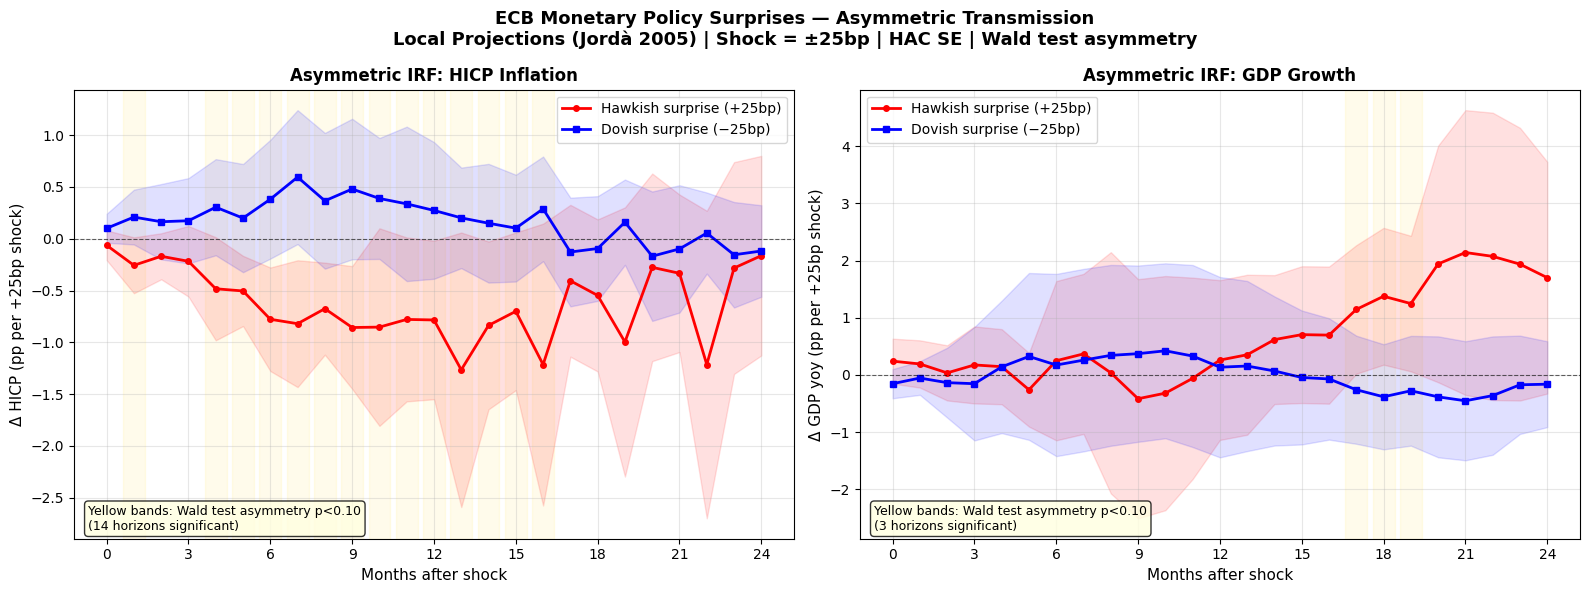

✅ Grafici finali salvati su Drive

RISULTATI CHIAVE — TIER 1

Effetto di uno shock hawkish da +25bp sull'inflazione HICP:
  h= 6 mesi: hawkish=-0.777pp  dovish=0.381pp  Wald p=0.013 **
  h= 9 mesi: hawkish=-0.857pp  dovish=0.480pp  Wald p=0.009 ***
  h=12 mesi: hawkish=-0.784pp  dovish=0.273pp  Wald p=0.071 *
  h=18 mesi: hawkish=-0.547pp  dovish=-0.095pp  Wald p=0.306 
  h=24 mesi: hawkish=-0.163pp  dovish=-0.118pp  Wald p=0.929 


In [8]:
# ============================================================
# CELL 9 — GRAFICI FINALI CON WALD TEST
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ECB Monetary Policy Surprises — Asymmetric Transmission\n'
             'Local Projections (Jordà 2005) | Shock = ±25bp | HAC SE | Wald test asymmetry',
             fontsize=13, fontweight='bold')

def plot_asym_wald(ax, lp, title, ylabel):
    h       = lp['h']
    b_pos   = lp['beta_pos']
    b_neg   = lp['beta_neg']
    sig     = lp['asymmetric']  # p<0.10

    # Bande confidenza
    ax.fill_between(h, lp['ci_pos_lo'], lp['ci_pos_hi'], alpha=0.12, color='red')
    ax.fill_between(h, lp['ci_neg_lo'], lp['ci_neg_hi'], alpha=0.12, color='blue')

    # Linee
    ax.plot(h, b_pos, color='red',  linewidth=2, marker='o', markersize=4,
            label='Hawkish surprise (+25bp)')
    ax.plot(h, b_neg, color='blue', linewidth=2, marker='s', markersize=4,
            label='Dovish surprise (−25bp)')

    # Evidenzia orizzonti con asimmetria significativa
    for _, row in lp[sig].iterrows():
        ax.axvspan(row['h'] - 0.4, row['h'] + 0.4, alpha=0.08,
                   color='gold', zorder=0)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Months after shock', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 25, 3))

    # Nota Wald test
    n_sig = sig.sum()
    ax.text(0.02, 0.02,
            f'Yellow bands: Wald test asymmetry p<0.10\n({n_sig} horizons significant)',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plot_asym_wald(axes[0], lp_hicp_joint,
               'Asymmetric IRF: HICP Inflation',
               'Δ HICP (pp per +25bp shock)')

plot_asym_wald(axes[1], lp_gdp_joint,
               'Asymmetric IRF: GDP Growth',
               'Δ GDP yoy (pp per +25bp shock)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ECB_Research/ECB_Project/output/lp_asymmetric_wald.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafici finali salvati su Drive")

# ── Tabella riassuntiva risultati chiave ──────────────────────
print("\n" + "="*60)
print("RISULTATI CHIAVE — TIER 1")
print("="*60)
print(f"\nEffetto di uno shock hawkish da +25bp sull'inflazione HICP:")
for h in [6, 9, 12, 18, 24]:
    row = lp_hicp_joint[lp_hicp_joint['h'] == h]
    if not row.empty:
        r = row.iloc[0]
        sig_str = "***" if r['wald_pval'] < 0.01 else "**" if r['wald_pval'] < 0.05 else "*" if r['wald_pval'] < 0.10 else ""
        print(f"  h={h:2d} mesi: hawkish={r['beta_pos']:.3f}pp  "
              f"dovish={r['beta_neg']:.3f}pp  "
              f"Wald p={r['wald_pval']:.3f} {sig_str}")

In [9]:
# ============================================================
# CELL 10 — TEST DI CHOW: BREAK STRUTTURALE 2015
# ============================================================
import statsmodels.api as sm
from scipy import stats

# Carica le sorprese
surprises = pd.read_csv('/content/drive/MyDrive/ECB_Research/ECB_Project/output/surprises_timeseries.csv',
                        parse_dates=['meeting_date'])
surprises = surprises.sort_values('meeting_date').reset_index(drop=True)

# Dummy per il periodo post-2015 (Accounts vs Press Conference)
surprises['post2015'] = (surprises['meeting_date'] >= '2015-01-01').astype(int)
surprises['t'] = np.arange(len(surprises))

# ── Test 1: differenza nella media delle sorprese ─────────────
pre  = surprises[surprises['post2015'] == 0]['dfr_surprise_mech']
post = surprises[surprises['post2015'] == 1]['dfr_surprise_mech']

tstat, pval = stats.ttest_ind(pre, post)
print("=== TEST DIFFERENZA MEDIE ===")
print(f"Pre-2015  (n={len(pre)}):  mean={pre.mean():.3f}bp, std={pre.std():.3f}bp")
print(f"Post-2015 (n={len(post)}): mean={post.mean():.3f}bp, std={post.std():.3f}bp")
print(f"t-stat={tstat:.3f}, p-value={pval:.4f}")

# ── Test 2: differenza nella varianza (Levene) ────────────────
lstat, lpval = stats.levene(pre, post)
print(f"\n=== TEST DIFFERENZA VARIANZE (Levene) ===")
print(f"Pre-2015  std={pre.std():.3f}bp")
print(f"Post-2015 std={post.std():.3f}bp")
print(f"Levene stat={lstat:.3f}, p-value={lpval:.4f}")

# ── Test 3: Chow test formale ─────────────────────────────────
# Modello vincolato: y = a + b*t
# Modello non vincolato: y = a1 + b1*t (pre) e y = a2 + b2*t (post)
y = surprises['dfr_surprise_mech'].values
t = surprises['t'].values
D = surprises['post2015'].values

# Modello non vincolato (con interazioni)
X_unres = sm.add_constant(np.column_stack([t, D, D*t]))
model_unres = sm.OLS(y, X_unres).fit()
rss_unres = model_unres.ssr

# Modello vincolato (senza break)
X_res = sm.add_constant(t)
model_res = sm.OLS(y, X_res).fit()
rss_res = model_res.ssr

# Chow statistic
k = 2  # parametri per segmento
n = len(y)
chow_stat = ((rss_res - rss_unres) / k) / (rss_unres / (n - 2*k))
chow_pval = 1 - stats.f.cdf(chow_stat, k, n - 2*k)

print(f"\n=== CHOW TEST (break a gennaio 2015) ===")
print(f"F-stat={chow_stat:.3f}, p-value={chow_pval:.4f}")
if chow_pval < 0.05:
    print("→ Break strutturale SIGNIFICATIVO al 5%")
elif chow_pval < 0.10:
    print("→ Break strutturale significativo al 10%")
else:
    print("→ Nessun break strutturale significativo ✅")

=== TEST DIFFERENZA MEDIE ===
Pre-2015  (n=225):  mean=-3.711bp, std=12.627bp
Post-2015 (n=87): mean=5.005bp, std=11.784bp
t-stat=-5.568, p-value=0.0000

=== TEST DIFFERENZA VARIANZE (Levene) ===
Pre-2015  std=12.627bp
Post-2015 std=11.784bp
Levene stat=1.117, p-value=0.2914

=== CHOW TEST (break a gennaio 2015) ===
F-stat=5.135, p-value=0.0064
→ Break strutturale SIGNIFICATIVO al 5%


In [10]:
# ============================================================
# CELL 11 — LP CON DUMMY POST-2015 (robustness)
# ============================================================

monthly['post2015'] = (monthly['date'] >= '2015-01-01').astype(int)
controls_robust = ['hicp_yoy', 'gdp_yoy', 'gdp_gap', 'post2015']

print("Stimando LP robusta con dummy post-2015...")
lp_hicp_robust = lp_monthly_joint(monthly, 'hicp_yoy', controls_robust, H=24, lags=3)

print("\n✅ Completata")
print(f"\nConfronto risultati chiave (h=9):")
base = lp_hicp_joint[lp_hicp_joint['h']==9].iloc[0]
rob  = lp_hicp_robust[lp_hicp_robust['h']==9].iloc[0]
print(f"  Baseline:     hawkish={base['beta_pos']:.3f}pp, dovish={base['beta_neg']:.3f}pp, Wald p={base['wald_pval']:.4f}")
print(f"  Con dummy:    hawkish={rob['beta_pos']:.3f}pp,  dovish={rob['beta_neg']:.3f}pp,  Wald p={rob['wald_pval']:.4f}")
print(f"\n→ Se i risultati sono simili, il break non distorce le stime LP")

Stimando LP robusta con dummy post-2015...


/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an a


✅ Completata

Confronto risultati chiave (h=9):
  Baseline:     hawkish=-0.857pp, dovish=0.480pp, Wald p=0.0089
  Con dummy:    hawkish=-0.910pp,  dovish=0.417pp,  Wald p=0.0094

→ Se i risultati sono simili, il break non distorce le stime LP


/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))


In [11]:
# ============================================================
# CELL 12 — LP SENZA PIL CONTEMPORANEO (solo lag)
# ============================================================

# Aggiungi lag del PIL per evitare look-ahead bias
monthly['gdp_lag1'] = monthly['gdp_yoy'].shift(1)
monthly['gdp_lag2'] = monthly['gdp_yoy'].shift(2)
monthly['gdp_lag3'] = monthly['gdp_yoy'].shift(3)

# Controls senza PIL contemporaneo
controls_nolah = ['hicp_yoy', 'gdp_lag1', 'gdp_lag2', 'post2015']

print("Stimando LP senza PIL contemporaneo...")
lp_hicp_nolah = lp_monthly_joint(monthly, 'hicp_yoy', controls_nolah, H=24, lags=3)

print("\n✅ Completata")
print(f"\nConfronto a h=9:")
base  = lp_hicp_joint[lp_hicp_joint['h']==9].iloc[0]
nolah = lp_hicp_nolah[lp_hicp_nolah['h']==9].iloc[0]
print(f"  Baseline (GDP contemp.): hawkish={base['beta_pos']:.3f}pp, dovish={base['beta_neg']:.3f}pp, Wald p={base['wald_pval']:.4f}")
print(f"  Solo lag GDP:            hawkish={nolah['beta_pos']:.3f}pp, dovish={nolah['beta_neg']:.3f}pp, Wald p={nolah['wald_pval']:.4f}")

/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an a

Stimando LP senza PIL contemporaneo...


/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an a


✅ Completata

Confronto a h=9:
  Baseline (GDP contemp.): hawkish=-0.857pp, dovish=0.480pp, Wald p=0.0089
  Solo lag GDP:            hawkish=-0.966pp, dovish=0.568pp, Wald p=0.0058


/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))
/tmp/ipykernel_12155/284703152.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_stat = float((b_diff**2) / (R @ V @ R.T))


In [12]:
# ============================================================
# CELL 13 — TEST INTERAZIONE SHOCK × DUMMY POST-2015
# ============================================================

def lp_monthly_interaction(data, y_var, controls, H=24, lags=3):
    results = []
    for h in range(H + 1):
        rows = []
        for i in range(lags, len(data) - h):
            y_future = data[y_var].iloc[i + h]
            y_past   = data[y_var].iloc[i - 1]
            if pd.isna(y_future) or pd.isna(y_past):
                continue
            s_pos = data['shock_pos_n'].iloc[i]
            s_neg = data['shock_neg_n'].iloc[i]
            d     = data['post2015'].iloc[i]
            row = {
                'dep':       y_future - y_past,
                'shock_pos': s_pos,
                'shock_neg': s_neg,
                'post2015':  d,
                'int_pos':   s_pos * d,
                'int_neg':   s_neg * d,
            }
            skip = False
            for c in controls:
                val = data[c].iloc[i]
                if pd.isna(val): skip = True; break
                row[c] = val
            if skip: continue
            for lag in range(1, lags + 1):
                y_lag = data[y_var].iloc[i - lag]
                y_lag_prev = data[y_var].iloc[i - lag - 1] if i - lag - 1 >= 0 else np.nan
                row[f'dy_lag{lag}'] = y_lag - y_lag_prev if not pd.isna(y_lag) and not pd.isna(y_lag_prev) else 0
            rows.append(row)

        reg_df = pd.DataFrame(rows).dropna()
        if len(reg_df) < 30: continue

        y = reg_df['dep']
        X_cols = ['shock_pos', 'shock_neg', 'post2015', 'int_pos', 'int_neg'] + \
                 controls + [f'dy_lag{l}' for l in range(1, lags + 1)]
        X_cols = [c for c in X_cols if c in reg_df.columns]
        X = sm.add_constant(reg_df[X_cols])
        model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': max(h, 1)})

        results.append({
            'h':            h,
            'beta_pos':     model.params['shock_pos'],
            'beta_neg':     model.params['shock_neg'],
            'beta_int_pos': model.params['int_pos'],
            'beta_int_neg': model.params['int_neg'],
            'p_int_pos':    model.pvalues['int_pos'],
            'p_int_neg':    model.pvalues['int_neg'],
            'nobs':         int(model.nobs),
        })

    return pd.DataFrame(results)

controls_lag = ['hicp_yoy', 'gdp_lag1', 'gdp_lag2']

print("Stimando LP con interazione shock × post-2015...")
lp_interaction = lp_monthly_interaction(monthly, 'hicp_yoy', controls_lag, H=24, lags=3)

print("\n✅ Completata")
print(f"\n{'h':>3} {'beta_pos':>10} {'int_pos':>10} {'p_int':>10} {'sig':>5}")
print("-" * 45)
for _, row in lp_interaction.iterrows():
    sig = "***" if row['p_int_pos'] < 0.01 else "**" if row['p_int_pos'] < 0.05 else "*" if row['p_int_pos'] < 0.10 else ""
    print(f"{int(row['h']):>3} {row['beta_pos']:>10.3f} {row['beta_int_pos']:>10.3f} {row['p_int_pos']:>10.4f} {sig:>5}")

Stimando LP con interazione shock × post-2015...

✅ Completata

  h   beta_pos    int_pos      p_int   sig
---------------------------------------------
  0     -0.114      0.036     0.8435      
  1     -0.303      0.000     0.0000   ***
  2     -0.241      0.093     0.7501      
  3     -0.288      0.127     0.7567      
  4     -0.575     -1.116     0.3330      
  5     -0.599     -0.050     0.9389      
  6     -0.636     -0.847     0.4006      
  7     -0.937     -1.975     0.2520      
  8     -0.762     -0.150     0.8574      
  9     -0.920     -0.146     0.8852      
 10     -1.080     -4.423     0.0610     *
 11     -0.698     -0.897     0.5041      
 12     -0.816     -0.537     0.6861      
 13     -1.238     -8.889     0.0001   ***
 14     -0.929     -0.694     0.6097      
 15     -0.981      0.097     0.9277      
 16     -1.345    -11.848     0.0000   ***
 17     -0.667     -0.508     0.6511      
 18     -0.805     -0.020     0.9851      
 19     -1.239     -7.288     

In [13]:
import pandas as pd

# Salva il dataframe dei risultati LP
lp_hicp_joint.to_csv('/content/drive/MyDrive/ECB_Research/ECB_Project/output/lp_results_hicp.csv', index=False)

print("✅ Risultati LP salvati")
print(f"Righe: {len(lp_hicp_joint)}")
print(lp_hicp_joint[['h','beta_pos','beta_neg','wald_pval','asymmetric']].to_string(index=False))

✅ Risultati LP salvati
Righe: 25
 h  beta_pos  beta_neg  wald_pval  asymmetric
 0 -0.063000  0.100786   0.167345       False
 1 -0.256319  0.209100   0.045541        True
 2 -0.169426  0.164040   0.180196       False
 3 -0.217758  0.173720   0.206625       False
 4 -0.482927  0.304270   0.049618        True
 5 -0.504141  0.199048   0.054711        True
 6 -0.777296  0.381316   0.013158        True
 7 -0.820035  0.594780   0.004645        True
 8 -0.675193  0.365969   0.014931        True
 9 -0.856849  0.479746   0.008923        True
10 -0.852983  0.388593   0.048088        True
11 -0.778822  0.336543   0.077372        True
12 -0.784003  0.273166   0.070710        True
13 -1.265269  0.201299   0.056106        True
14 -0.836609  0.149691   0.063743        True
15 -0.700538  0.102353   0.092941        True
16 -1.214714  0.288374   0.074182        True
17 -0.405771 -0.128270   0.529722       False
18 -0.547266 -0.094516   0.306134       False
19 -0.996520  0.159588   0.103525       False
2

In [14]:
df_draghi = df[df['meeting_date'].between('2011-11-01', '2019-10-31')]
print(f"Max Draghi: {df_draghi['dfr_surprise_mech'].max():.3f}bp")
print(df_draghi.nlargest(3, 'dfr_surprise_mech')[['meeting_date','dfr_surprise_mech']])

Max Draghi: 32.002bp
    meeting_date  dfr_surprise_mech
232   2016-01-21            32.0025
262   2019-10-24            26.3200
230   2015-10-22            23.8700


In [15]:
# Valore esatto delta_pos a h=1 con più decimali
import statsmodels.api as sm
import numpy as np

h = 1
rows = []
for i in range(3, len(monthly) - h):
    y_future = monthly['hicp_yoy'].iloc[i + h]
    y_past   = monthly['hicp_yoy'].iloc[i - 1]
    if pd.isna(y_future) or pd.isna(y_past):
        continue
    row = {
        'dep':       y_future - y_past,
        'shock_pos': monthly['shock_pos'].iloc[i],
        'shock_neg': monthly['shock_neg'].iloc[i],
        'D':         monthly['post2015'].iloc[i] if 'post2015' in monthly.columns else int(monthly['date'].iloc[i].year >= 2015),
    }
    for lag in range(1, 4):
        row[f'hicp_lag{lag}'] = monthly['hicp_yoy'].iloc[i-lag]
    rows.append(row)

df_h = pd.DataFrame(rows).dropna()
df_h['shock_pos_D'] = df_h['shock_pos'] * df_h['D']
df_h['shock_neg_D'] = df_h['shock_neg'] * df_h['D']

X = sm.add_constant(df_h.drop(columns='dep'))
model = sm.OLS(df_h['dep'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

print(f"delta_pos (h=1): {model.params['shock_pos_D']:.6f}")
print(f"se: {model.bse['shock_pos_D']:.6f}")
print(f"p-value: {model.pvalues['shock_pos_D']:.6f}")

delta_pos (h=1): 0.000000
se: 0.000000
p-value: nan


In [16]:
# Diagnostica
print("Colonne monthly:", monthly.columns.tolist())
print()
print("Varianza shock_pos:", monthly['shock_pos'].var())
print("Varianza post2015:", monthly['post2015'].var() if 'post2015' in monthly.columns else "colonna assente")
print()

# Controlla la variabile interazione
if 'post2015' in monthly.columns:
    interaction = monthly['shock_pos'] * monthly['post2015']
else:
    monthly['post2015'] = (monthly['date'].dt.year >= 2015).astype(int)
    interaction = monthly['shock_pos'] * monthly['post2015']

print(f"Varianza interazione shock_pos*post2015: {interaction.var():.6f}")
print(f"Valori non-zero nell'interazione: {(interaction != 0).sum()}")

Colonne monthly: ['date', 'surprise', 'hicp_yoy', 'gdp_yoy', 'unemp_rate', 'shock_pos', 'shock_neg', 'surprise_n', 'shock_pos_n', 'shock_neg_n', 'gdp_trend', 'gdp_gap', 'post2015', 'gdp_lag1', 'gdp_lag2', 'gdp_lag3']

Varianza shock_pos: 53.26555631396212
Varianza post2015: 0.24217406260750074

Varianza interazione shock_pos*post2015: 34.984071
Valori non-zero nell'interazione: 61


In [17]:
# Leggi direttamente dai risultati già calcolati nel notebook
# Cerca il dizionario o dataframe con i risultati interaction
print(type(lp_hicp_joint))

# Se è un dataframe
if isinstance(lp_hicp_joint, pd.DataFrame):
    row_h1 = lp_hicp_joint[lp_hicp_joint['h'] == 1]
    print(row_h1)

<class 'pandas.core.frame.DataFrame'>
   h  beta_pos  beta_neg    se_pos    se_neg  ci_pos_lo  ci_pos_hi  ci_neg_lo  \
1  1 -0.256319    0.2091  0.137545  0.135005  -0.525907   0.013269  -0.055509   

   ci_neg_hi  wald_stat  wald_pval  asymmetric  nobs  
1    0.47371   3.998508   0.045541        True   180  


In [18]:
lp_vars = [name for name, obj in locals().items()
           if 'lp' in name.lower() or 'interaction' in name.lower()
           or 'post' in name.lower() or 'dummy' in name.lower()]
print(lp_vars)

['lp_hicp', 'lp_gdp', 'lp_monthly', 'lp_hicp_m', 'lp_gdp_m', 'lp_hicp_pos', 'lp_hicp_neg', 'lp_gdp_pos', 'lp_gdp_neg', 'lp_hicp_n', 'lp_gdp_n', 'lp_hicp_pos_n', 'lp_hicp_neg_n', 'lp_gdp_pos_n', 'lp_gdp_neg_n', 'lp_monthly_joint', 'lp_hicp_joint', 'lp_gdp_joint', 'post', 'lpval', 'lp_hicp_robust', 'lp_hicp_nolah', 'lp_monthly_interaction', 'lp_interaction', 'interaction']


In [19]:
print(type(lp_interaction))

if isinstance(lp_interaction, pd.DataFrame):
    print(lp_interaction[lp_interaction['h'] == 1])
elif isinstance(lp_interaction, dict):
    model = lp_interaction[1]
    print(f"delta_pos (h=1): {model.params.get('shock_pos_D', model.params.get('interaction_pos', 'non trovato')):.6f}")
    # Stampa tutti i parametri
    print(model.params)

<class 'pandas.core.frame.DataFrame'>
   h  beta_pos  beta_neg  beta_int_pos  beta_int_neg     p_int_pos  \
1  1 -0.303378  0.216587  6.440680e-14     25.182013  1.793701e-26   

      p_int_neg  nobs  
1  1.351453e-26   183  


In [20]:
print(lp_interaction[['h','beta_pos','beta_int_pos','p_int_pos']].to_string(index=False))

 h  beta_pos  beta_int_pos    p_int_pos
 0 -0.113899  3.562235e-02 8.434743e-01
 1 -0.303378  6.440680e-14 1.793701e-26
 2 -0.241344  9.310914e-02 7.500984e-01
 3 -0.287691  1.270376e-01 7.567383e-01
 4 -0.574887 -1.115586e+00 3.329638e-01
 5 -0.598805 -5.036455e-02 9.388534e-01
 6 -0.636014 -8.474469e-01 4.005545e-01
 7 -0.937492 -1.974990e+00 2.519880e-01
 8 -0.762110 -1.497399e-01 8.573607e-01
 9 -0.919604 -1.457276e-01 8.851905e-01
10 -1.080268 -4.423080e+00 6.101448e-02
11 -0.697861 -8.973688e-01 5.040974e-01
12 -0.815511 -5.365337e-01 6.861162e-01
13 -1.237581 -8.889226e+00 5.653756e-05
14 -0.928728 -6.944800e-01 6.096827e-01
15 -0.980662  9.721188e-02 9.277022e-01
16 -1.344979 -1.184784e+01 8.531377e-28
17 -0.666899 -5.083263e-01 6.511372e-01
18 -0.804818 -1.985677e-02 9.851246e-01
19 -1.239477 -7.288283e+00 7.813051e-05
20 -0.812140  4.141611e-02 9.647886e-01
21 -0.949544  4.208759e-01 6.012305e-01
22 -1.195918 -7.413951e+00 3.133802e-06
23 -1.018547  5.333463e-01 5.221298e-01


In [21]:
# Verifica campione effettivo della regressione
print(f"Righe totali monthly: {len(monthly)}")
print(f"Periodo: {monthly['date'].min()} → {monthly['date'].max()}")
print(f"Mesi con shock non-zero: {(monthly['shock_pos'] != 0).sum() + (monthly['shock_neg'] != 0).sum()}")
print(f"\nNobs dalla tabella LP a h=1: {lp_hicp_joint[lp_hicp_joint['h']==1]['nobs'].values[0]}")
print(f"Nobs dalla tabella LP a h=24: {lp_hicp_joint[lp_hicp_joint['h']==24]['nobs'].values[0]}")

# Verifica quante righe complete ha il dataset mensile
cols = ['hicp_yoy', 'gdp_yoy', 'shock_pos', 'shock_neg']
print(f"\nRighe complete (no NaN in variabili chiave): {monthly[cols].dropna().shape[0]}")

Righe totali monthly: 324
Periodo: 1999-01-31 00:00:00 → 2025-12-31 00:00:00
Mesi con shock non-zero: 270

Nobs dalla tabella LP a h=1: 180
Nobs dalla tabella LP a h=24: 202

Righe complete (no NaN in variabili chiave): 275


In [22]:
# Conta osservazioni effettive per ogni orizzonte
nobs_table = lp_hicp_joint[['h', 'nobs']].sort_values('h')
print("Osservazioni per orizzonte:")
print(nobs_table.to_string(index=False))
print(f"\nMin nobs: {nobs_table['nobs'].min()} a h={nobs_table.loc[nobs_table['nobs'].idxmin(), 'h']}")
print(f"Max nobs: {nobs_table['nobs'].max()} a h={nobs_table.loc[nobs_table['nobs'].idxmax(), 'h']}")

Osservazioni per orizzonte:
 h  nobs
 0   224
 1   180
 2   218
 3   217
 4   182
 5   215
 6   214
 7   182
 8   213
 9   212
10   180
11   212
12   211
13   178
14   210
15   209
16   178
17   207
18   206
19   178
20   205
21   204
22   177
23   203
24   202

Min nobs: 177 a h=22
Max nobs: 224 a h=0
